# FGSM / PGD: Day 12 (plain VQC accuracy) + Day 19 (MAQT acceptance)
## BoT-IoT | Full Training Checkpoint
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd

import json
from pathlib import Path

In [2]:
from scripts.constants import (
    DEFAULT_ALPHA, DEFAULT_BATCH_SIZE, DEFAULT_CF,
    DEFAULT_NOISE_RATE, DEFAULT_SEED, ZERO_DAY, DEFAULT_BETA,
)
from scripts.data import load_split, to_angles
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.utils import get_torch_device, to_np_y, to_torch_batch_x
from scripts.attacks import fgsm_attack, pgd_attack, eval_attacked
from scripts.quantum_metrics import stack_prototypes, max_fidelity_to_prototypes
from scripts.inference import qsnet_infer_batch
from scripts.theory import (
    analytic_lipschitz_bound,
    fgsm_gradient_sign,
    apply_fgsm_perturbation,
    pgd_attack_nonconformity,
    linf_to_l2_budget,
    worst_case_f_in,
    proposition2_epsilon_star,
    proposition2_epsilon_beta,
    is_eps_safe_to_plot,
)

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"PennyLane version: {qp.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.12.1+cu126
PennyLane version: 0.45.1
CUDA available: True


## Config

In [4]:
NOTEBOOK_NAME = "12,19.fgsm-pgd-bot-iot"
VQC_NOTEBOOK = "final-bot-iot-vqc-train"
MAQT_NOTEBOOK = "final-bot-iot-maqt-train"
ALGO3_MAQT_NAME = "final-bot-iot-algo3-cached (maqt)"

dataset = "BoT-IoT"
target_col = "label_multiclass"
data_path = f"data/FROZEN/{dataset}"
frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"
ARTIFACTS_DIR = Path("final_notebooks") / "final_artifacts"

SEED = DEFAULT_SEED
batch_size = DEFAULT_BATCH_SIZE

# day 12 — CE-head attacks on plain VQC
N_DAY12_TEST = 1000          # subsample test for CE attack speed (None = all)
EPS_SNAPSHOT = 0.1           # bar-plot epsilon (L_inf on angles)
PGD_STEPS = 10

# day 19 — novelty attacks on MAQT + conformal q
N_KNOWN_ACCEPTED = 300
BREAKPOINT_ACCEPT = 0.99
EPS_INF_FGSM = [0.0, 0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3]
EPS_INF_PGD = [0.0, 0.05, 0.1, 0.2, 0.3]
FGSM_BATCH = 32
PGD_BATCH = 16

## Load Team C's FROZEN Features

In [5]:
handoff = json.loads(Path(frozen_feat_path).read_text())
FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Team C selector: QIGPSO
k=10 features: ['n_pkts_total', 'n_bytes_total', 'src_bytes', 'rate', 'pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'pkt_size_std', 'protocol', 'conn_state']


## Load Team A's FROZEN Splits

Test for attacks; no EDA / balancing / retrain.

In [6]:
X_test_raw, y_test, class_names, df_test = load_split(
    data_path, "test", target_col, categories=None, csv=True,
    selected_cols=FEATURE_COLS, return_df=True,
)
X_zero_raw, y_zero, _, df_zero = load_split(
    data_path, "zeroday", target_col, categories=None, csv=True,
    selected_cols=FEATURE_COLS, return_df=True,
)

print(f"test   : {X_test_raw.shape}, y={y_test.shape}")
print(f"zeroday: {X_zero_raw.shape}, y={y_zero.shape}")
print(f"classes: {class_names}")
df_test.head(3)

test   : (18591, 10), y=(18591,)
zeroday: (683, 10), y=(683,)
classes: ['DDoS', 'DoS', 'Normal', 'Reconnaissance']


,n_pkts_total,n_bytes_total,src_bytes,rate,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,protocol,conn_state,label_multiclass
0,1.179250,0.579671,0.801334,0.707583,1.508626,0.019794,0.445853,0.028953,0.0,0.0,DoS
1,-0.952073,-1.533888,-1.615819,-0.173549,0.000000,0.178138,0.115554,1.068753,0.0,0.0,DoS
2,-2.131323,-1.758058,-1.872189,-1.122783,0.000000,-0.863767,-0.609676,-0.274325,-1.0,-1.0,DoS


## Load Day-23 Checkpoints (+ Algo-3 $q$)

- **VQC** → Day 12 CE-head accuracy under FGSM/PGD
- **MAQT** → Day 19 novelty / acceptance under FGSM/PGD
- **Algo-3 MAQT artifact** → frozen conformal $q$ and $L_\varphi$ (no recalibration)

In [7]:
def unpack_train_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    theta = ckpt["theta"]
    if not isinstance(theta, torch.nn.Parameter):
        theta = torch.nn.Parameter(theta)
    prototypes = {int(k): v for k, v in ckpt["prototypes"].items()}
    class_names_ck = list(ckpt.get("class_names", class_names))
    num_classes = int(ckpt.get("num_classes", len(class_names_ck)))
    num_qubits = int(ckpt["num_qubits"])
    num_layers = int(ckpt.get("num_layers", 2))
    noise_rate = float(ckpt.get("noise_rate", DEFAULT_NOISE_RATE))
    scaler = ckpt["scaler"]
    pca = ckpt.get("pca")
    use_pca = bool(ckpt.get("use_pca", pca is not None))
    x_min = np.asarray(ckpt["angle_x_min"])
    x_max = np.asarray(ckpt["angle_x_max"])
    angle_max = float(ckpt.get("angle_max", np.pi))
    head = None
    if "head_state_dict" in ckpt:
        head = nn.Linear(num_qubits, num_classes)
        head.load_state_dict(ckpt["head_state_dict"])
    return {
        "path": ckpt_path,
        "theta": theta,
        "prototypes": prototypes,
        "head": head,
        "class_names": class_names_ck,
        "num_classes": num_classes,
        "num_qubits": num_qubits,
        "num_layers": num_layers,
        "noise_rate": noise_rate,
        "scaler": scaler,
        "pca": pca if use_pca else None,
        "use_pca": use_pca,
        "x_min": x_min,
        "x_max": x_max,
        "angle_max": angle_max,
    }


vqc_path = ARTIFACTS_DIR / f"{VQC_NOTEBOOK}-checkpoint.pt"
maqt_path = ARTIFACTS_DIR / f"{MAQT_NOTEBOOK}-checkpoint.pt"
algo3_path = ARTIFACTS_DIR / f"{ALGO3_MAQT_NAME}.pt"

for p in (vqc_path, maqt_path, algo3_path):
    if not p.exists():
        raise FileNotFoundError(f"missing artifact: {p}")

vqc = unpack_train_ckpt(vqc_path)
maqt = unpack_train_ckpt(maqt_path)
algo3 = torch.load(algo3_path, map_location="cpu", weights_only=False)

q = float(algo3["q"])
L_phi = float(algo3.get("L_phi", analytic_lipschitz_bound(maqt["num_layers"], reupload=True)))
Cf = float(algo3.get("C_f", DEFAULT_CF))
alpha = float(algo3.get("alpha", DEFAULT_ALPHA))

print(f"VQC : {vqc_path}")
print(f"  theta={tuple(vqc['theta'].shape)} qubits={vqc['num_qubits']} layers={vqc['num_layers']} head={vqc['head'] is not None}")
print()
print(f"MAQT: {maqt_path}")
print(f"  theta={tuple(maqt['theta'].shape)} qubits={maqt['num_qubits']} layers={maqt['num_layers']} protos={len(maqt['prototypes'])}")
print()
print(f"Algo3 MAQT: {algo3_path}")
print(f"  q={q:.6f}  L_phi={L_phi:.4f}  Cf={Cf}  alpha={alpha}")

VQC : final_notebooks/final_artifacts/final-bot-iot-vqc-train-checkpoint.pt
  theta=(2, 5, 3) qubits=5 layers=2 head=True

MAQT: final_notebooks/final_artifacts/final-bot-iot-maqt-train-checkpoint.pt
  theta=(2, 5, 3) qubits=5 layers=2 protos=4

Algo3 MAQT: final_notebooks/final_artifacts/final-bot-iot-algo3-cached (maqt).pt
  q=0.285916  L_phi=1.0000  Cf=1.0  alpha=0.05


## Mapping Features $\rightarrow$ [0, $\pi$]

Each model keeps its own train-fitted scaler / PCA / angle bounds.

In [8]:
A_test_vqc = to_angles(
    X_test_raw, vqc["scaler"], vqc["x_min"], vqc["x_max"],
    pca=vqc["pca"], angle_max=vqc["angle_max"],
)
A_test_maqt = to_angles(
    X_test_raw, maqt["scaler"], maqt["x_min"], maqt["x_max"],
    pca=maqt["pca"], angle_max=maqt["angle_max"],
)
A_zero_maqt = to_angles(
    X_zero_raw, maqt["scaler"], maqt["x_min"], maqt["x_max"],
    pca=maqt["pca"], angle_max=maqt["angle_max"],
)

print(f"angles VQC test : {A_test_vqc.shape} | USE_PCA={vqc['use_pca']}")
print(f"angles MAQT test: {A_test_maqt.shape} | USE_PCA={maqt['use_pca']}")
print(f"angles MAQT zero: {A_zero_maqt.shape}   | USE_PCA={maqt['use_pca']}")

angles VQC test : (18591, 5) | USE_PCA=True
angles MAQT test: (18591, 5) | USE_PCA=True
angles MAQT zero: (683, 5)   | USE_PCA=True


## Quantum Circuit

In [9]:
device = get_torch_device()

dev_vqc = create_quantum_device(vqc["num_qubits"])
fc_vqc = build_forward_circuit(dev_vqc, vqc["num_qubits"], vqc["num_layers"], noise_rate=vqc["noise_rate"])
theta_vqc = vqc["theta"].to(device)
if not isinstance(theta_vqc, torch.nn.Parameter):
    theta_vqc = torch.nn.Parameter(theta_vqc)
head_vqc = vqc["head"].to(device)
head_vqc.eval()

dev_maqt = create_quantum_device(maqt["num_qubits"])
fc_maqt = build_forward_circuit(dev_maqt, maqt["num_qubits"], maqt["num_layers"], noise_rate=maqt["noise_rate"])
theta_maqt = maqt["theta"].to(device)
if not isinstance(theta_maqt, torch.nn.Parameter):
    theta_maqt = torch.nn.Parameter(theta_maqt)
prototypes_maqt = {int(k): v.to(device) for k, v in maqt["prototypes"].items()}

x_min_vqc = torch.tensor(0.0, device=device)
x_max_vqc = torch.tensor(float(vqc["angle_max"]), device=device)
x_min_maqt = 0.0
x_max_maqt = float(maqt["angle_max"])

print(f"device={device}")
print(f"VQC  qubits={vqc['num_qubits']} layers={vqc['num_layers']} noise={vqc['noise_rate']}")
print(f"MAQT qubits={maqt['num_qubits']} layers={maqt['num_layers']} noise={maqt['noise_rate']}")

device=cuda
VQC  qubits=5 layers=2 noise=0.01
MAQT qubits=5 layers=2 noise=0.01


## Day 12 — Plain VQC: FGSM / PGD degrade CE accuracy

Attack maximizes CE loss on the classifier head, on encoded angles.

In [10]:
rng = np.random.default_rng(SEED)
y_test_np = to_np_y(y_test).astype(int)

if N_DAY12_TEST is not None and len(A_test_vqc) > N_DAY12_TEST:
    # class-balanced random subsample
    classes = sorted(np.unique(y_test_np))
    n_per = max(1, N_DAY12_TEST // len(classes))
    idx_parts = []
    for c in classes:
        idx_c = np.where(y_test_np == c)[0]
        take = min(len(idx_c), n_per)
        idx_parts.append(rng.choice(idx_c, size=take, replace=False))
    day12_idx = np.concatenate(idx_parts)
    if len(day12_idx) < N_DAY12_TEST:
        remain = np.setdiff1d(np.arange(len(y_test_np)), day12_idx, assume_unique=False)
        extra_n = min(len(remain), N_DAY12_TEST - len(day12_idx))
        if extra_n > 0:
            day12_idx = np.concatenate([day12_idx, rng.choice(remain, size=extra_n, replace=False)])
    elif len(day12_idx) > N_DAY12_TEST:
        day12_idx = rng.choice(day12_idx, size=N_DAY12_TEST, replace=False)
else:
    day12_idx = np.arange(len(A_test_vqc))

A12 = A_test_vqc[day12_idx]
y12 = y_test_np[day12_idx]
label_ids = list(range(vqc["num_classes"]))

print(f"Day-12 eval n={len(A12)} (of {len(A_test_vqc)} test)")

clean = eval_attacked(
    fgsm_attack, A12, y12, theta_vqc, head_vqc, fc_vqc, device,
    labels=label_ids, batch_size=batch_size, eps=0.0,
    x_min=x_min_vqc, x_max=x_max_vqc,
)
fgsm = eval_attacked(
    fgsm_attack, A12, y12, theta_vqc, head_vqc, fc_vqc, device,
    labels=label_ids, batch_size=batch_size, eps=EPS_SNAPSHOT,
    x_min=x_min_vqc, x_max=x_max_vqc,
)
pgd_alpha = max(EPS_SNAPSHOT / PGD_STEPS, 1e-4)
pgd = eval_attacked(
    pgd_attack, A12, y12, theta_vqc, head_vqc, fc_vqc, device,
    labels=label_ids, batch_size=max(8, batch_size // 2),
    eps=EPS_SNAPSHOT, alpha=pgd_alpha, steps=PGD_STEPS,
    x_min=x_min_vqc, x_max=x_max_vqc,
)

print()
print(f"clean : acc={clean['acc']:.4f}  macro-F1={clean['macro_f1']:.4f}")
print(f"FGSM  : acc={fgsm['acc']:.4f}  macro-F1={fgsm['macro_f1']:.4f}  (eps={EPS_SNAPSHOT})")
print(f"PGD   : acc={pgd['acc']:.4f}  macro-F1={pgd['macro_f1']:.4f}  (eps={EPS_SNAPSHOT}, steps={PGD_STEPS})")
print(f"FGSM drop (acc): {clean['acc'] - fgsm['acc']:+.4f}")
print(f"PGD  drop (acc): {clean['acc'] - pgd['acc']:+.4f}")

if clean["acc"] <= 0:
    raise RuntimeError("clean acc is 0: check VQC checkpoint / angles")
fgsm_hurt = (fgsm["acc"] < clean["acc"]) or (fgsm["macro_f1"] < clean["macro_f1"])
pgd_hurt = (pgd["acc"] < clean["acc"]) or (pgd["macro_f1"] < clean["macro_f1"])
print()
if fgsm_hurt and pgd_hurt:
    print("[OK]: both attacks degrade VQC accuracy/F1 vs clean")
else:
    print("[WARNING]: expected both attacks to degrade accuracy/F1")
    if not fgsm_hurt:
        print("  FGSM did not degrade")
    if not pgd_hurt:
        print("  PGD did not degrade")

Day-12 eval n=1000 (of 18591 test)

clean : acc=0.8030  macro-F1=0.7999
FGSM  : acc=0.2090  macro-F1=0.2246  (eps=0.1)
PGD   : acc=0.3450  macro-F1=0.3587  (eps=0.1, steps=10)
FGSM drop (acc): +0.5940
PGD  drop (acc): +0.4580

[OK]: both attacks degrade VQC accuracy/F1 vs clean


## Day 19 — MAQT: FGSM / PGD on novelty score (acceptance)

Attack maximizes $s(x)=1-F_{\max}(x)$ (CQ-ZDR boundary).

### Metrics
- **acceptance rate**: fraction with $\hat y \neq$ `ZERO_DAY`
- **robust accuracy**: fraction with $\hat y = y$ (rejects count as wrong)

In [11]:
# clean Algo-3 labels on full known test (MAQT angles)
labels_clean, _, scores_clean, _ = qsnet_infer_batch(
    A_test_maqt, theta_maqt, prototypes_maqt, q, fc_maqt,
    p=maqt["noise_rate"], L_phi=L_phi, Cf=Cf, zero_day=ZERO_DAY,
    device=device, batch_size=batch_size,
)
accepted_idx = np.where(np.asarray(labels_clean) != ZERO_DAY)[0]
rng19 = np.random.default_rng(SEED)
n_take = min(N_KNOWN_ACCEPTED, len(accepted_idx))
attack_idx = rng19.choice(accepted_idx, size=n_take, replace=False)
X_attack = A_test_maqt[attack_idx]
y_attack = y_test_np[attack_idx]

print(f"known-accepted on clean test: {len(accepted_idx)} / {len(A_test_maqt)}")
print(f"Day-19 attack subset n={len(X_attack)}")

known-accepted on clean test: 17716 / 18591
Day-19 attack subset n=300


In [12]:
_, proto_stack = stack_prototypes(prototypes_maqt, device=device)

# one-pass FGSM direction for the whole sweep
grad_sign_fgsm = fgsm_gradient_sign(
    X_attack,
    theta_maqt,
    prototypes_maqt,
    fc_maqt,
    device=device,
    batch_size=FGSM_BATCH,
    proto_stack=proto_stack,
)
print(f"precomputed FGSM grad-sign shape: {tuple(grad_sign_fgsm.shape)}")

precomputed FGSM grad-sign shape: (300, 5)


In [13]:
# helpers
def eval_under_attack(X_adv_np, y_true_np):
    labels, _, scores, _ = qsnet_infer_batch(
        X_adv_np, theta_maqt, prototypes_maqt, q, fc_maqt,
        p=maqt["noise_rate"], L_phi=L_phi, Cf=Cf, zero_day=ZERO_DAY,
        device=device, batch_size=batch_size,
    )
    labels = np.asarray(labels)
    accepted = labels != ZERO_DAY
    return {
        "acceptance_rate": float(accepted.mean()),
        "robust_acc": float(np.mean(labels == y_true_np)),
        "mean_novelty": float(np.mean(scores)),
        "n_rejected": int((~accepted).sum()),
    }


def run_eps_sweep(attack_name):
    eps_list = EPS_INF_FGSM if attack_name == "fgsm" else EPS_INF_PGD
    bs = FGSM_BATCH if attack_name == "fgsm" else PGD_BATCH
    rows = []

    for eps_inf in eps_list:
        eps_l2 = float(linf_to_l2_budget(eps_inf, d=maqt["num_qubits"]))

        if eps_inf == 0.0:
            X_adv_np = X_attack

        elif attack_name == "fgsm":
            X_adv = apply_fgsm_perturbation(
                X_attack,
                grad_sign_fgsm,
                eps_inf,
                device=device,
                x_min=x_min_maqt,
                x_max=x_max_maqt,
            )
            X_adv_np = X_adv.detach().cpu().numpy()

        else:
            alpha_pgd = max(eps_inf / PGD_STEPS, 1e-4)
            X_adv = pgd_attack_nonconformity(
                X_attack,
                theta_maqt,
                prototypes_maqt,
                fc_maqt,
                eps=eps_inf,
                alpha=alpha_pgd,
                steps=PGD_STEPS,
                device=device,
                x_min=x_min_maqt,
                x_max=x_max_maqt,
                batch_size=bs,
                proto_stack=proto_stack,
            )
            X_adv_np = X_adv.detach().cpu().numpy()

        metrics = eval_under_attack(X_adv_np, y_attack)
        row = {"attack": attack_name, "eps_inf": eps_inf, "eps_l2": eps_l2, **metrics}
        rows.append(row)

        print(
            f"[{attack_name}] eps_inf={eps_inf:.3f} eps_l2={eps_l2:.4f} | "
            f"accept={metrics['acceptance_rate']:.4f} "
            f"robust_acc={metrics['robust_acc']:.4f} "
            f"rejected={metrics['n_rejected']}"
        )

    return pd.DataFrame(rows)


def empirical_breakpoint(df_attack, thresh=BREAKPOINT_ACCEPT):
    below = df_attack[df_attack["acceptance_rate"] < thresh]
    if len(below) == 0:
        return float("inf")
    return float(below["eps_l2"].iloc[0])

In [14]:
df_fgsm = run_eps_sweep("fgsm")
df_pgd = run_eps_sweep("pgd")
bp_fgsm = empirical_breakpoint(df_fgsm)
bp_pgd = empirical_breakpoint(df_pgd)
print(f"empirical breakpoint (accept<{BREAKPOINT_ACCEPT:g}): FGSM={bp_fgsm:.4f}  PGD={bp_pgd:.4f}")

[fgsm] eps_inf=0.000 eps_l2=0.0000 | accept=1.0000 robust_acc=0.5567 rejected=0
[fgsm] eps_inf=0.010 eps_l2=0.0224 | accept=0.9900 robust_acc=0.5567 rejected=3
[fgsm] eps_inf=0.020 eps_l2=0.0447 | accept=0.9867 robust_acc=0.5633 rejected=4
[fgsm] eps_inf=0.050 eps_l2=0.1118 | accept=0.9667 robust_acc=0.5633 rejected=10
[fgsm] eps_inf=0.080 eps_l2=0.1789 | accept=0.9433 robust_acc=0.5533 rejected=17
[fgsm] eps_inf=0.100 eps_l2=0.2236 | accept=0.9333 robust_acc=0.5500 rejected=20
[fgsm] eps_inf=0.150 eps_l2=0.3354 | accept=0.9233 robust_acc=0.5567 rejected=23
[fgsm] eps_inf=0.200 eps_l2=0.4472 | accept=0.8533 robust_acc=0.5100 rejected=44
[fgsm] eps_inf=0.300 eps_l2=0.6708 | accept=0.7167 robust_acc=0.3867 rejected=85
[pgd] eps_inf=0.000 eps_l2=0.0000 | accept=1.0000 robust_acc=0.5567 rejected=0
[pgd] eps_inf=0.050 eps_l2=0.1118 | accept=0.9767 robust_acc=0.5567 rejected=7
[pgd] eps_inf=0.100 eps_l2=0.2236 | accept=0.9567 robust_acc=0.5700 rejected=13
[pgd] eps_inf=0.200 eps_l2=0.4472 | 

## Visualization

In [15]:
# ============================================================
# Day 18 reference — Proposition 2 eps* (for Day 19 plot annotation)
# ============================================================
def compute_f_max_angles(A_angles, theta, prototypes, forward_circuit, device, batch_size=256):
    _, proto_stack_local = stack_prototypes(prototypes, device=device)
    chunks = []
    with torch.no_grad():
        for i in range(0, len(A_angles), batch_size):
            x_chunk = to_torch_batch_x(A_angles[i:i + batch_size], device=device)
            _, rho = forward_circuit(x_chunk, theta)
            fmax = max_fidelity_to_prototypes(rho, proto_stack_local)
            chunks.append(fmax.detach().cpu().numpy())
    return np.concatenate(chunks)


F_max_test = compute_f_max_angles(
    A_test_maqt, theta_maqt, prototypes_maqt, fc_maqt, device, batch_size=batch_size,
)
F_max_zeroday = compute_f_max_angles(
    A_zero_maqt, theta_maqt, prototypes_maqt, fc_maqt, device, batch_size=batch_size,
)

F_IN = worst_case_f_in(F_max_test, percentile=0.0)
F_OUT = float(F_max_zeroday.max())
delta_strict, eps_star_strict = proposition2_epsilon_star(
    F_IN, F_OUT, p=maqt["noise_rate"], L_phi=L_phi,
)
_, _, eps_star_beta = proposition2_epsilon_beta(
    F_IN, F_max_zeroday, L_phi=L_phi, p=maqt["noise_rate"], beta=DEFAULT_BETA,
)

print(f"F_in={F_IN:.4f}  F_out={F_OUT:.4f}")
print(
    f"Delta(strict)={delta_strict:+.4f}  eps*(strict)={eps_star_strict:.4f}"
    f"{' [VACUOUS]' if eps_star_strict <= 0 else ''}"
)
print(f"eps*(beta)={eps_star_beta:.4f}")

h3_holds = np.isfinite(bp_fgsm) and bp_fgsm >= eps_star_strict
print(
    f"H3 holds (empirical FGSM bp >= eps*): {h3_holds}"
    + ("  [VACUOUS: eps*<=0]" if eps_star_strict <= 0 else "")
)

F_in=0.3274  F_out=0.9275
Delta(strict)=-0.8724  eps*(strict)=-0.4406 [VACUOUS]
eps*(beta)=-0.4060
H3 holds (empirical FGSM bp >= eps*): True  [VACUOUS: eps*<=0]


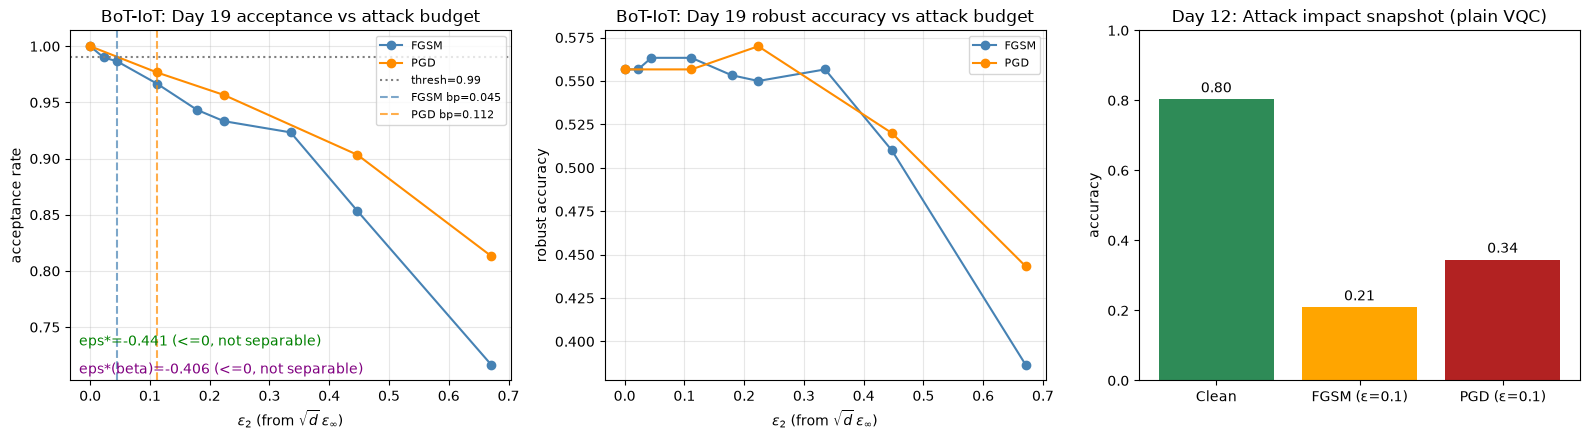

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- day 19: acceptance ---
for df_a, name, color in [
    (df_fgsm, "FGSM", "steelblue"),
    (df_pgd, "PGD", "darkorange"),
]:
    axes[0].plot(df_a["eps_l2"], df_a["acceptance_rate"], marker="o", color=color, label=name)

axes[0].axhline(BREAKPOINT_ACCEPT, color="gray", linestyle=":", label=f"thresh={BREAKPOINT_ACCEPT:g}")

# final-results style: certified eps* (strict)
eps_plot, is_safe = is_eps_safe_to_plot(eps_star_strict)
if is_safe:
    axes[0].axvline(
        eps_plot, color="green", linestyle="--",
        label=f"certified eps*={eps_plot:.3f}",
    )
else:
    axes[0].text(
        0.02, 0.10,
        f"eps*={eps_star_strict:.3f} (<=0, not separable)",
        transform=axes[0].transAxes,
        color="green",
    )

# same condition for beta-relaxed eps*
eps_plot_beta, is_safe_beta = is_eps_safe_to_plot(eps_star_beta)
if is_safe_beta:
    axes[0].axvline(
        eps_plot_beta, color="purple", linestyle=":",
        label=fr"Day-18 $\varepsilon^{{(\beta)}}_{{fmax}}$={eps_plot_beta:.3f}",
    )
else:
    axes[0].text(
        0.02, 0.02,
        f"eps*(beta)={eps_star_beta:.3f} (<=0, not separable)",
        transform=axes[0].transAxes,
        color="purple",
    )

if np.isfinite(bp_fgsm):
    axes[0].axvline(bp_fgsm, color="steelblue", linestyle="--", alpha=0.7, label=f"FGSM bp={bp_fgsm:.3f}")
if np.isfinite(bp_pgd):
    axes[0].axvline(bp_pgd, color="darkorange", linestyle="--", alpha=0.7, label=f"PGD bp={bp_pgd:.3f}")

axes[0].set_xlabel(r"$\varepsilon_2$ (from $\sqrt{d}\,\varepsilon_\infty$)")
axes[0].set_ylabel("acceptance rate")
axes[0].set_title(f"{dataset}: Day 19 acceptance vs attack budget")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- day 19: robust accuracy ---
for df_a, name, color in [
    (df_fgsm, "FGSM", "steelblue"),
    (df_pgd, "PGD", "darkorange"),
]:
    axes[1].plot(df_a["eps_l2"], df_a["robust_acc"], marker="o", color=color, label=name)

axes[1].set_xlabel(r"$\varepsilon_2$ (from $\sqrt{d}\,\varepsilon_\infty$)")
axes[1].set_ylabel("robust accuracy")
axes[1].set_title(f"{dataset}: Day 19 robust accuracy vs attack budget")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# --- day 12: attack impact snapshot ---
bars = axes[2].bar(
    ["Clean", f"FGSM (ε={EPS_SNAPSHOT})", f"PGD (ε={EPS_SNAPSHOT})"],
    [clean["acc"], fgsm["acc"], pgd["acc"]],
    color=["seagreen", "orange", "firebrick"],
)
axes[2].set_ylabel("accuracy")
axes[2].set_ylim(0, 1)
axes[2].set_title("Day 12: Attack impact snapshot (plain VQC)")
for b in bars:
    axes[2].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.02,
        f"{b.get_height():.2f}",
        ha="center",
    )

plt.tight_layout()
plt.show()

## Logging

In [17]:
out_dir = Path("logs")
out_dir.mkdir(parents=True, exist_ok=True)
log_path = out_dir / f"{NOTEBOOK_NAME}.log"

lines = [
    f"notebook={NOTEBOOK_NAME}",
    f"dataset={dataset}",
    f"vqc_checkpoint={vqc_path}",
    f"maqt_checkpoint={maqt_path}",
    f"algo3_artifact={algo3_path}",
    f"q={q:.6f}",
    f"L_phi={L_phi:.6f}",
    f"day12_n={len(A12)}",
    f"day12_eps={EPS_SNAPSHOT}",
    f"day12_clean_acc={clean['acc']:.6f}",
    f"day12_fgsm_acc={fgsm['acc']:.6f}",
    f"day12_pgd_acc={pgd['acc']:.6f}",
    f"day12_fgsm_drop={clean['acc'] - fgsm['acc']:+.6f}",
    f"day12_pgd_drop={clean['acc'] - pgd['acc']:+.6f}",
    f"day12_fgsm_hurt={bool(fgsm_hurt)}",
    f"day12_pgd_hurt={bool(pgd_hurt)}",

    f"day19_n={len(X_attack)}",
    f"day19_bp_fgsm={bp_fgsm}",
    f"day19_bp_pgd={bp_pgd}",

    f"F_in={F_IN:.6f}",
    f"F_out={F_OUT:.6f}",
    f"delta_strict={delta_strict:.6f}",
    f"eps_star_strict={eps_star_strict:.6f}",
    f"eps_star_beta={eps_star_beta:.6f}",
    f"eps_star_strict_vacuous={bool(eps_star_strict <= 0)}",
    f"eps_star_beta_vacuous={bool(eps_star_beta <= 0)}",
    f"H3_holds={bool(h3_holds)}",
]
for _, row in df_fgsm.iterrows():
    lines.append(
        f"fgsm eps_inf={row['eps_inf']:.3f} accept={row['acceptance_rate']:.6f} robust_acc={row['robust_acc']:.6f}"
    )
for _, row in df_pgd.iterrows():
    lines.append(
        f"pgd eps_inf={row['eps_inf']:.3f} accept={row['acceptance_rate']:.6f} robust_acc={row['robust_acc']:.6f}"
    )

log_path.write_text("\n".join(lines) + "\n")
print(f"wrote {log_path}")

wrote logs/12,19.fgsm-pgd-bot-iot.log
